# 04 - Model Engineering: Preparación de Datos y Entrenamiento de Modelos Base

Este notebook prepara los datos históricos del dólar argentino y entrena los siguientes modelos:
- **ARIMA**: Modelo autorregresivo para predicción de precio
- **GARCH**: Modelo de volatilidad condicional
- **LightGBM**: Gradient boosting con features engineered
- **N-BEATS**: Deep learning para forecasting

Los modelos entrenados se exportarán para crear un ensemble en el notebook 05.

## 1. Importación de Librerías

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import json
import pickle
import os

# Modelos estadísticos
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model

# Machine Learning
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Deep Learning (opcional)
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TF_AVAILABLE = True
    print('✓ TensorFlow disponible')
except ImportError as e:
    TF_AVAILABLE = False
    print('⚠ TensorFlow no disponible. N-BEATS será omitido.')
    print(f'  Error: {str(e)[:100]}...')

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print('\n✓ Librerías importadas correctamente')
if TF_AVAILABLE:
    print(f'TensorFlow version: {tf.__version__}')
print(f'LightGBM version: {lgb.__version__}')

⚠ TensorFlow no disponible. N-BEATS será omitido.
  Error: Traceback (most recent call last):
  File "c:\Users\davos\OneDrive\Documentos\UCASAL\Segundo Año\Seg...

✓ Librerías importadas correctamente
LightGBM version: 4.6.0


## 2. Carga y Exploración de Datos

In [7]:
# Cargar datos históricos de todos los tipos de dólar
data_files = {
    'oficial': '../data/raw/history/history_oficial.parquet',
    'blue': '../data/raw/history/history_blue.parquet',
    'mayorista': '../data/raw/history/history_mayorista.parquet',
    'ccl': '../data/raw/history/history_contadoconliqui.parquet'
}

dfs = {}
for name, file_path in data_files.items():
    df = pd.read_parquet(file_path)
    df['fecha'] = pd.to_datetime(df['fecha'])
    df = df.sort_values('fecha').reset_index(drop=True)
    dfs[name] = df
    print(f'{name.upper()}: {len(df)} registros desde {df["fecha"].min()} hasta {df["fecha"].max()}')

print('\n✓ Datos cargados correctamente')

OFICIAL: 5445 registros desde 2011-01-03 00:00:00 hasta 2025-11-29 00:00:00
BLUE: 5445 registros desde 2011-01-03 00:00:00 hasta 2025-11-29 00:00:00
MAYORISTA: 5305 registros desde 2011-01-03 00:00:00 hasta 2025-11-29 00:00:00
CCL: 4547 registros desde 2013-01-02 00:00:00 hasta 2025-11-29 00:00:00

✓ Datos cargados correctamente


In [8]:
# Visualizar primeros registros de cada tipo
for name, df in dfs.items():
    print(f'\n{name.upper()}:')
    display(df.head())
    print(f'Info: {df.info()}')


OFICIAL:


,casa,compra,venta,fecha
0,oficial,4.0,4.0,2011-01-03
1,oficial,4.0,4.0,2011-01-04
2,oficial,4.0,4.0,2011-01-05
3,oficial,4.0,4.0,2011-01-06
4,oficial,4.0,4.0,2011-01-07


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5445 entries, 0 to 5444
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   casa    5445 non-null   object        
 1   compra  5445 non-null   float64       
 2   venta   5445 non-null   float64       
 3   fecha   5445 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 170.3+ KB
Info: None

BLUE:


,casa,compra,venta,fecha
0,blue,4.0,4.0,2011-01-03
1,blue,4.0,4.0,2011-01-04
2,blue,4.0,4.0,2011-01-05
3,blue,4.0,4.0,2011-01-06
4,blue,4.0,4.0,2011-01-07


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5445 entries, 0 to 5444
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   casa    5445 non-null   object        
 1   compra  5445 non-null   float64       
 2   venta   5445 non-null   float64       
 3   fecha   5445 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 170.3+ KB
Info: None

MAYORISTA:


,casa,compra,venta,fecha
0,mayorista,3.97,3.98,2011-01-03
1,mayorista,3.97,3.98,2011-01-04
2,mayorista,3.97,3.98,2011-01-05
3,mayorista,3.97,3.98,2011-01-06
4,mayorista,3.97,3.98,2011-01-07


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5305 entries, 0 to 5304
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   casa    5305 non-null   object        
 1   compra  5305 non-null   float64       
 2   venta   5305 non-null   float64       
 3   fecha   5305 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 165.9+ KB
Info: None

CCL:


,casa,compra,venta,fecha
0,contadoconliqui,6.67,6.67,2013-01-02
1,contadoconliqui,6.68,6.68,2013-01-03
2,contadoconliqui,6.82,6.82,2013-01-04
3,contadoconliqui,6.82,6.82,2013-01-05
4,contadoconliqui,6.82,6.82,2013-01-06


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4547 entries, 0 to 4546
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   casa    4547 non-null   object        
 1   compra  4547 non-null   float64       
 2   venta   4547 non-null   float64       
 3   fecha   4547 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 142.2+ KB
Info: None


## 3. Consolidación y Limpieza de Datos

In [9]:
# Consolidar todos los tipos de dólar en un único DataFrame
def consolidate_data(dfs):
    """
    Consolida múltiples DataFrames de tipos de dólar en uno solo.
    """
    consolidated = None
    
    for tipo, df in dfs.items():
        # Calcular precio promedio (compra + venta) / 2
        df_temp = df.copy()
        df_temp[f'precio_{tipo}'] = (df_temp['compra'] + df_temp['venta']) / 2
        df_temp[f'spread_{tipo}'] = df_temp['venta'] - df_temp['compra']
        
        # Seleccionar columnas relevantes
        df_temp = df_temp[['fecha', f'precio_{tipo}', f'spread_{tipo}']]
        
        if consolidated is None:
            consolidated = df_temp
        else:
            consolidated = pd.merge(consolidated, df_temp, on='fecha', how='outer')
    
    # Ordenar por fecha
    consolidated = consolidated.sort_values('fecha').reset_index(drop=True)
    
    return consolidated

df_consolidated = consolidate_data(dfs)
print(f'Datos consolidados: {len(df_consolidated)} registros')
print(f'Rango de fechas: {df_consolidated["fecha"].min()} a {df_consolidated["fecha"].max()}')
print(f'\nColumnas: {df_consolidated.columns.tolist()}')
df_consolidated.head(10)

Datos consolidados: 5445 registros
Rango de fechas: 2011-01-03 00:00:00 a 2025-11-29 00:00:00

Columnas: ['fecha', 'precio_oficial', 'spread_oficial', 'precio_blue', 'spread_blue', 'precio_mayorista', 'spread_mayorista', 'precio_ccl', 'spread_ccl']


,fecha,precio_oficial,spread_oficial,precio_blue,spread_blue,precio_mayorista,spread_mayorista,precio_ccl,spread_ccl
0,2011-01-03,4.0,0.0,4.0,0.0,3.975,0.01,NaN,NaN
1,2011-01-04,4.0,0.0,4.0,0.0,3.975,0.01,NaN,NaN
2,2011-01-05,4.0,0.0,4.0,0.0,3.975,0.01,NaN,NaN
3,2011-01-06,4.0,0.0,4.0,0.0,3.975,0.01,NaN,NaN
4,2011-01-07,4.0,0.0,4.0,0.0,3.975,0.01,NaN,NaN
5,2011-01-08,4.0,0.0,4.0,0.0,3.975,0.01,NaN,NaN
6,2011-01-09,4.0,0.0,4.0,0.0,3.975,0.01,NaN,NaN
7,2011-01-10,4.0,0.0,4.0,0.0,3.980,0.00,NaN,NaN
8,2011-01-11,4.0,0.0,4.0,0.0,3.980,0.00,NaN,NaN
9,2011-01-12,4.0,0.0,4.0,0.0,3.980,0.00,NaN,NaN


In [10]:
# Verificar valores nulos
print('Valores nulos por columna:')
print(df_consolidated.isnull().sum())
print(f'\nPorcentaje de nulos:')
print((df_consolidated.isnull().sum() / len(df_consolidated) * 100).round(2))

Valores nulos por columna:
fecha                 0
precio_oficial        0
spread_oficial        0
precio_blue           0
spread_blue           0
precio_mayorista    140
spread_mayorista    140
precio_ccl          898
spread_ccl          898
dtype: int64

Porcentaje de nulos:
fecha                0.00
precio_oficial       0.00
spread_oficial       0.00
precio_blue          0.00
spread_blue          0.00
precio_mayorista     2.57
spread_mayorista     2.57
precio_ccl          16.49
spread_ccl          16.49
dtype: float64


In [11]:
# Imputación de valores nulos (forward fill)
df_clean = df_consolidated.copy()
df_clean = df_clean.fillna(method='ffill').fillna(method='bfill')

print('Valores nulos después de imputación:')
print(df_clean.isnull().sum())
print('\n✓ Datos limpios')

Valores nulos después de imputación:
fecha               0
precio_oficial      0
spread_oficial      0
precio_blue         0
spread_blue         0
precio_mayorista    0
spread_mayorista    0
precio_ccl          0
spread_ccl          0
dtype: int64

✓ Datos limpios


## 4. Feature Engineering

In [14]:
def create_features(df, target_col='precio_blue'):
    """
    Crea features para modelos de ML.
    """
    df = df.copy()
    
    # 1. Lags de precio
    for lag in [1, 2, 3, 5, 7, 14, 30]:
        df[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)
    
    # 2. Medias móviles
    for window in [7, 14, 20, 30, 60, 90]:
        df[f'{target_col}_ma_{window}'] = df[target_col].rolling(window=window).mean()
        df[f'{target_col}_std_{window}'] = df[target_col].rolling(window=window).std()
    
    # 3. Retornos
    df[f'{target_col}_return_1d'] = df[target_col].pct_change(1)
    df[f'{target_col}_return_7d'] = df[target_col].pct_change(7)
    df[f'{target_col}_return_30d'] = df[target_col].pct_change(30)
    
    # 4. Volatilidad histórica
    df[f'{target_col}_volatility_7d'] = df[f'{target_col}_return_1d'].rolling(window=7).std() * np.sqrt(365)
    df[f'{target_col}_volatility_30d'] = df[f'{target_col}_return_1d'].rolling(window=30).std() * np.sqrt(365)
    
    # 5. Indicadores técnicos
    # RSI (Relative Strength Index)
    delta = df[target_col].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df[f'{target_col}_rsi'] = 100 - (100 / (1 + rs))
    
    # MACD
    ema_12 = df[target_col].ewm(span=12, adjust=False).mean()
    ema_26 = df[target_col].ewm(span=26, adjust=False).mean()
    df[f'{target_col}_macd'] = ema_12 - ema_26
    df[f'{target_col}_macd_signal'] = df[f'{target_col}_macd'].ewm(span=9, adjust=False).mean()
    
    # Bollinger Bands
    df[f'{target_col}_bb_upper'] = df[f'{target_col}_ma_20'] + 2 * df[f'{target_col}_std_20']
    df[f'{target_col}_bb_lower'] = df[f'{target_col}_ma_20'] - 2 * df[f'{target_col}_std_20']
    df[f'{target_col}_bb_width'] = df[f'{target_col}_bb_upper'] - df[f'{target_col}_bb_lower']
    
    # 6. Brechas cambiarias
    if 'precio_oficial' in df.columns and 'precio_blue' in df.columns:
        df['brecha_blue_oficial'] = ((df['precio_blue'] - df['precio_oficial']) / df['precio_oficial']) * 100
    
    if 'precio_oficial' in df.columns and 'precio_ccl' in df.columns:
        df['brecha_ccl_oficial'] = ((df['precio_ccl'] - df['precio_oficial']) / df['precio_oficial']) * 100
    
    # 7. Features temporales
    df['dia_semana'] = df['fecha'].dt.dayofweek
    df['dia_mes'] = df['fecha'].dt.day
    df['mes'] = df['fecha'].dt.month
    df['trimestre'] = df['fecha'].dt.quarter
    df['año'] = df['fecha'].dt.year
    df['dia_año'] = df['fecha'].dt.dayofyear
    
    return df

# Crear features
df_features = create_features(df_clean, target_col='precio_blue')
print(f'Features creados: {len(df_features.columns)} columnas')
print(f'\nNuevas columnas: {[col for col in df_features.columns if col not in df_clean.columns]}')

Features creados: 47 columnas

Nuevas columnas: ['precio_blue_lag_1', 'precio_blue_lag_2', 'precio_blue_lag_3', 'precio_blue_lag_5', 'precio_blue_lag_7', 'precio_blue_lag_14', 'precio_blue_lag_30', 'precio_blue_ma_7', 'precio_blue_std_7', 'precio_blue_ma_14', 'precio_blue_std_14', 'precio_blue_ma_20', 'precio_blue_std_20', 'precio_blue_ma_30', 'precio_blue_std_30', 'precio_blue_ma_60', 'precio_blue_std_60', 'precio_blue_ma_90', 'precio_blue_std_90', 'precio_blue_return_1d', 'precio_blue_return_7d', 'precio_blue_return_30d', 'precio_blue_volatility_7d', 'precio_blue_volatility_30d', 'precio_blue_rsi', 'precio_blue_macd', 'precio_blue_macd_signal', 'precio_blue_bb_upper', 'precio_blue_bb_lower', 'precio_blue_bb_width', 'brecha_blue_oficial', 'brecha_ccl_oficial', 'dia_semana', 'dia_mes', 'mes', 'trimestre', 'año', 'dia_año']


In [15]:
# Eliminar filas con NaN (debido a lags y rolling windows)
df_features_clean = df_features.dropna().reset_index(drop=True)
print(f'Datos después de eliminar NaN: {len(df_features_clean)} registros')
print(f'Rango de fechas: {df_features_clean["fecha"].min()} a {df_features_clean["fecha"].max()}')

Datos después de eliminar NaN: 3919 registros
Rango de fechas: 2011-11-01 00:00:00 a 2025-11-29 00:00:00


## 5. División de Datos (Train/Validation/Test)

In [16]:
# División temporal: 70% train, 15% validation, 15% test
train_size = int(len(df_features_clean) * 0.70)
val_size = int(len(df_features_clean) * 0.15)

train_data = df_features_clean[:train_size]
val_data = df_features_clean[train_size:train_size + val_size]
test_data = df_features_clean[train_size + val_size:]

print(f'Train: {len(train_data)} registros ({train_data["fecha"].min()} a {train_data["fecha"].max()})')
print(f'Validation: {len(val_data)} registros ({val_data["fecha"].min()} a {val_data["fecha"].max()})')
print(f'Test: {len(test_data)} registros ({test_data["fecha"].min()} a {test_data["fecha"].max()})')

Train: 2743 registros (2011-11-01 00:00:00 a 2022-09-10 00:00:00)
Validation: 587 registros (2022-09-11 00:00:00 a 2024-04-19 00:00:00)
Test: 589 registros (2024-04-20 00:00:00 a 2025-11-29 00:00:00)


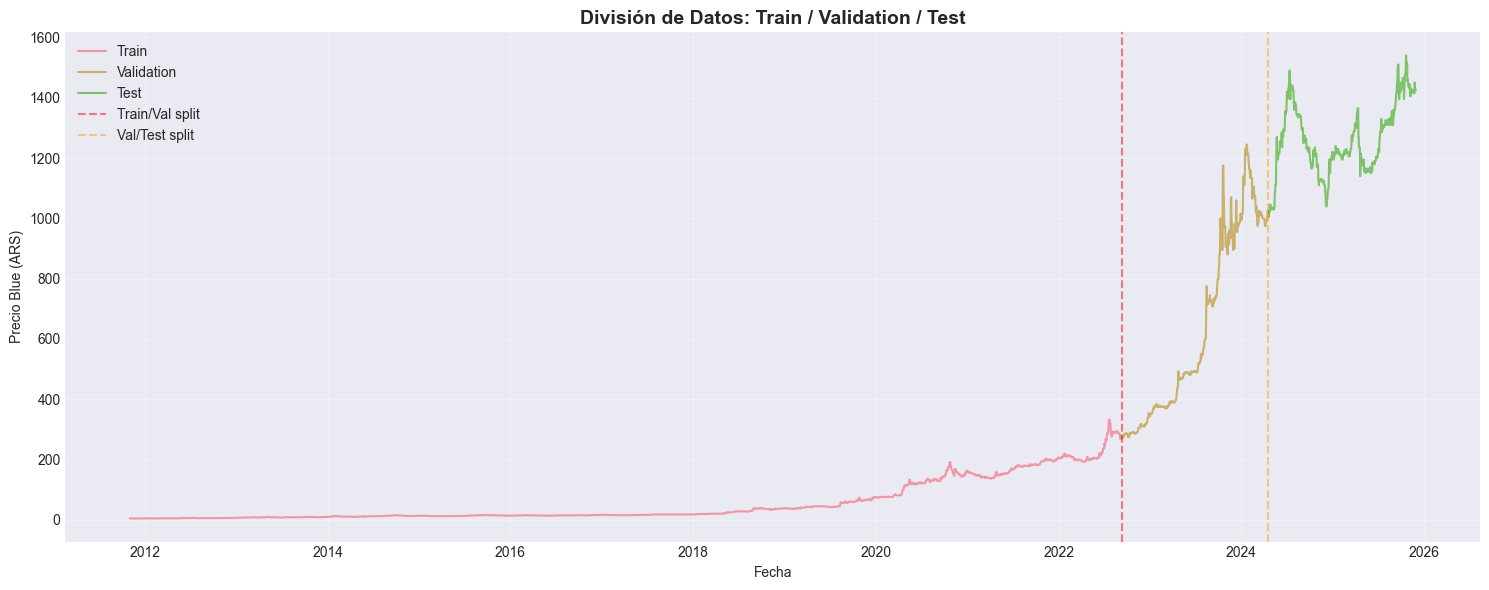

In [17]:
# Visualizar división de datos
plt.figure(figsize=(15, 6))
plt.plot(train_data['fecha'], train_data['precio_blue'], label='Train', alpha=0.7)
plt.plot(val_data['fecha'], val_data['precio_blue'], label='Validation', alpha=0.7)
plt.plot(test_data['fecha'], test_data['precio_blue'], label='Test', alpha=0.7)
plt.axvline(x=train_data['fecha'].iloc[-1], color='red', linestyle='--', alpha=0.5, label='Train/Val split')
plt.axvline(x=val_data['fecha'].iloc[-1], color='orange', linestyle='--', alpha=0.5, label='Val/Test split')
plt.title('División de Datos: Train / Validation / Test', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Precio Blue (ARS)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Guardar Datos Procesados

In [18]:
# Crear directorio para datos procesados
os.makedirs('data/processed', exist_ok=True)

# Guardar datasets
train_data.to_parquet('data/processed/train_data.parquet', index=False)
val_data.to_parquet('data/processed/val_data.parquet', index=False)
test_data.to_parquet('data/processed/test_data.parquet', index=False)
df_features_clean.to_parquet('data/processed/full_data_features.parquet', index=False)

print('✓ Datos guardados en data/processed/')
print('  - train_data.parquet')
print('  - val_data.parquet')
print('  - test_data.parquet')
print('  - full_data_features.parquet')

✓ Datos guardados en data/processed/
  - train_data.parquet
  - val_data.parquet
  - test_data.parquet
  - full_data_features.parquet


## 7. Modelo 1: ARIMA

In [19]:
# Preparar datos para ARIMA (solo precio blue)
y_train_arima = train_data['precio_blue'].values
y_val_arima = val_data['precio_blue'].values
y_test_arima = test_data['precio_blue'].values

print(f'Train shape: {y_train_arima.shape}')
print(f'Val shape: {y_val_arima.shape}')
print(f'Test shape: {y_test_arima.shape}')

Train shape: (2743,)
Val shape: (587,)
Test shape: (589,)


In [20]:
# Entrenar ARIMA
print('Entrenando modelo ARIMA...')
arima_order = (5, 1, 2)  # (p, d, q) - ajustar según ACF/PACF

arima_model = ARIMA(y_train_arima, order=arima_order)
arima_fit = arima_model.fit()

print('\n✓ Modelo ARIMA entrenado')
print(arima_fit.summary())

Entrenando modelo ARIMA...

✓ Modelo ARIMA entrenado
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2743
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -5031.668
Date:                Sun, 30 Nov 2025   AIC                          10079.337
Time:                        20:08:08   BIC                          10126.668
Sample:                             0   HQIC                         10096.440
                               - 2743                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2837      0.029     -9.811      0.000      -0.340      -0.227
ar.L2         -0.6147      0.032    -19.469      0.000      -0.677      -0.553

In [21]:
# Predicciones ARIMA
arima_pred_val = arima_fit.forecast(steps=len(y_val_arima))

# Métricas en validation
arima_mae_val = mean_absolute_error(y_val_arima, arima_pred_val)
arima_rmse_val = np.sqrt(mean_squared_error(y_val_arima, arima_pred_val))
arima_mape_val = np.mean(np.abs((y_val_arima - arima_pred_val) / y_val_arima)) * 100

print('Métricas ARIMA en Validation:')
print(f'MAE: {arima_mae_val:.2f}')
print(f'RMSE: {arima_rmse_val:.2f}')
print(f'MAPE: {arima_mape_val:.2f}%')

Métricas ARIMA en Validation:
MAE: 366.80
RMSE: 476.58
MAPE: 46.42%


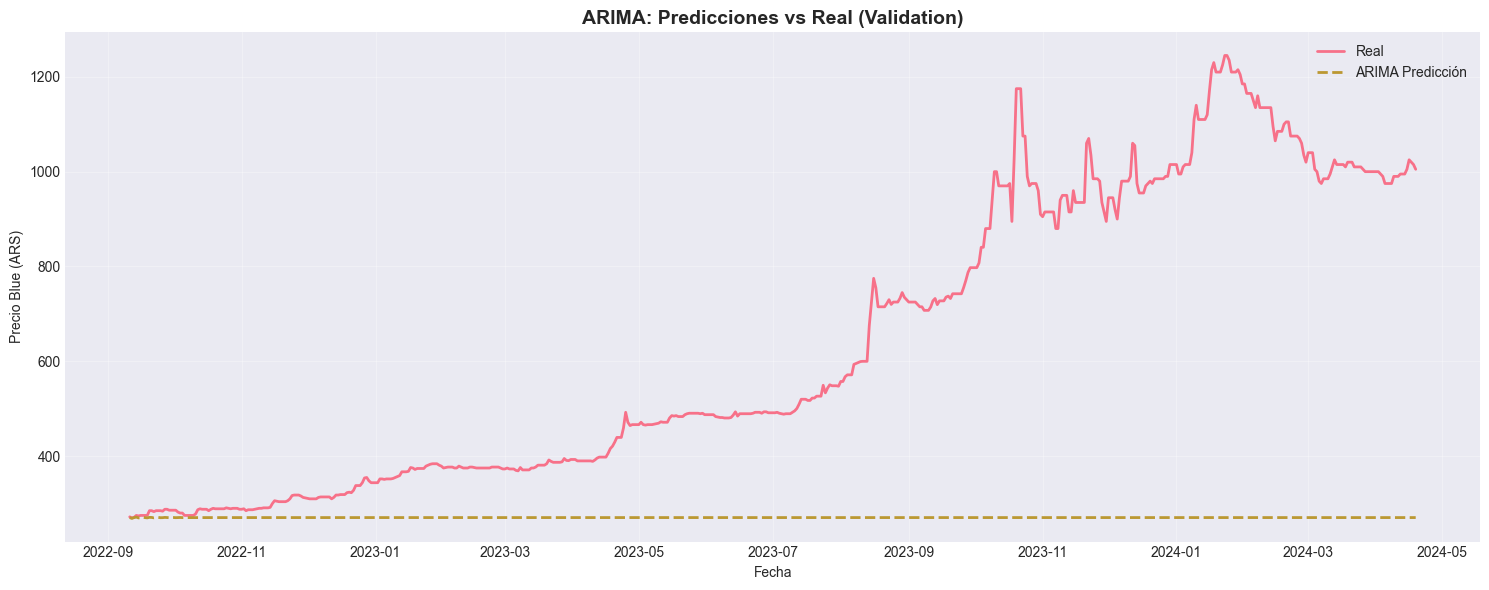

In [22]:
# Visualizar predicciones ARIMA
plt.figure(figsize=(15, 6))
plt.plot(val_data['fecha'], y_val_arima, label='Real', linewidth=2)
plt.plot(val_data['fecha'], arima_pred_val, label='ARIMA Predicción', linestyle='--', linewidth=2)
plt.title('ARIMA: Predicciones vs Real (Validation)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Precio Blue (ARS)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# Guardar modelo ARIMA
os.makedirs('../src/models/models', exist_ok=True)
with open('../src/models/models/arima_model.pkl', 'wb') as f:
    pickle.dump(arima_fit, f)

# Guardar predicciones
arima_results = {
    'model_name': 'ARIMA',
    'order': arima_order,
    'predictions_val': arima_pred_val.tolist(),
    'metrics_val': {
        'mae': float(arima_mae_val),
        'rmse': float(arima_rmse_val),
        'mape': float(arima_mape_val)
    }
}

with open('../src/models/models/arima_results.json', 'w') as f:
    json.dump(arima_results, f, indent=4)

print('✓ Modelo ARIMA guardado en ../src/models/models/')

✓ Modelo ARIMA guardado en ../src/models/models/


## 8. Modelo 2: GARCH (Volatilidad)

In [25]:
# Calcular retornos para GARCH
returns_train = train_data['precio_blue'].pct_change().dropna() * 100  # En porcentaje
returns_val = val_data['precio_blue'].pct_change().dropna() * 100

print(f'Retornos train: {len(returns_train)}')
print(f'Retornos val: {len(returns_val)}')
print(f'\nEstadísticas de retornos (train):')
print(returns_train.describe())

Retornos train: 2742
Retornos val: 586

Estadísticas de retornos (train):
count    2742.000000
mean        0.160796
std         1.737277
min       -14.285714
25%         0.000000
50%         0.000000
75%         0.000000
max        13.432836
Name: precio_blue, dtype: float64


In [26]:
# Entrenar GARCH(1,1)
print('Entrenando modelo GARCH(1,1)...')
garch_model = arch_model(returns_train, vol='Garch', p=1, q=1, rescale=False)
garch_fit = garch_model.fit(disp='off')

print('\n✓ Modelo GARCH entrenado')
print(garch_fit.summary())

Entrenando modelo GARCH(1,1)...

✓ Modelo GARCH entrenado
                     Constant Mean - GARCH Model Results                      
Dep. Variable:            precio_blue   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5086.89
Distribution:                  Normal   AIC:                           10181.8
Method:            Maximum Likelihood   BIC:                           10205.5
                                        No. Observations:                 2742
Date:                Sun, Nov 30 2025   Df Residuals:                     2741
Time:                        20:14:46   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu    

In [27]:
# Predicción de volatilidad
garch_forecast = garch_fit.forecast(horizon=len(returns_val), reindex=False)
predicted_volatility = np.sqrt(garch_forecast.variance.values[-1, :])

print(f'Volatilidad predicha (primeros 10 días): {predicted_volatility[:10]}')

Volatilidad predicha (primeros 10 días): [1.8731439  1.87197466 1.87081204 1.86965601 1.86850653 1.86736357
 1.86622709 1.86509706 1.86397346 1.86285624]


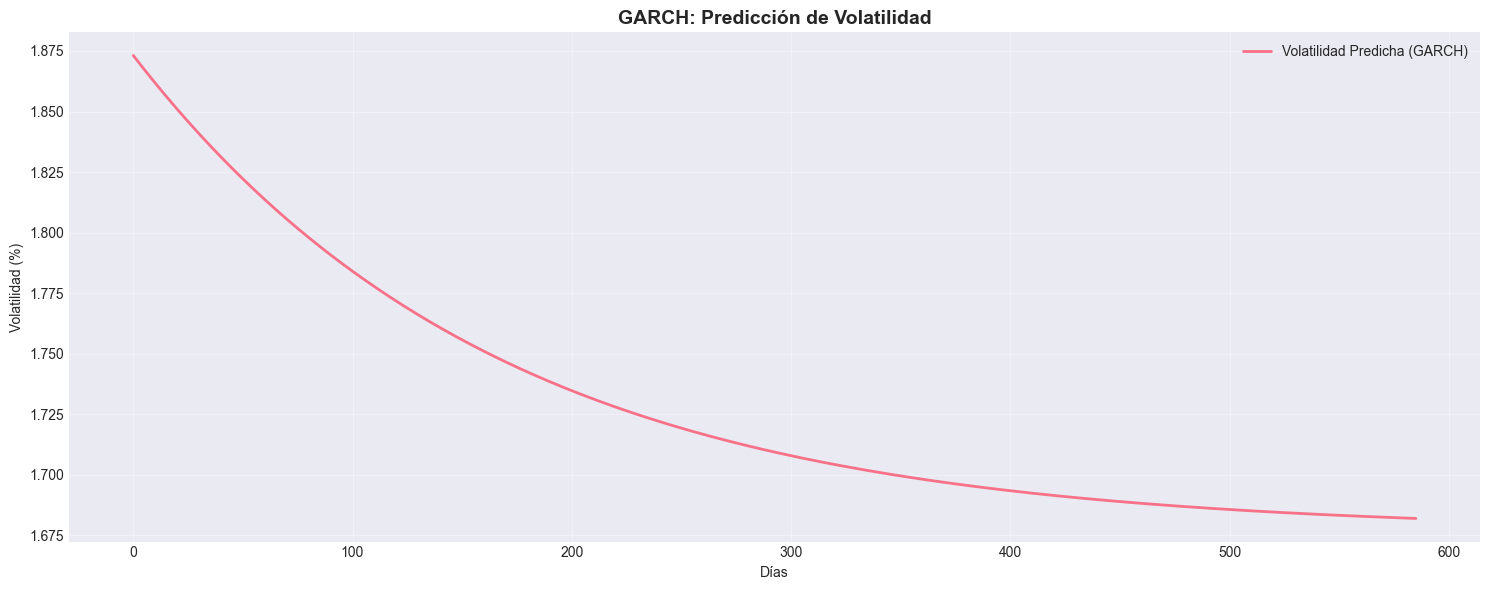

In [28]:
# Visualizar volatilidad
plt.figure(figsize=(15, 6))
plt.plot(predicted_volatility, label='Volatilidad Predicha (GARCH)', linewidth=2)
plt.title('GARCH: Predicción de Volatilidad', fontsize=14, fontweight='bold')
plt.xlabel('Días')
plt.ylabel('Volatilidad (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# Guardar modelo GARCH
with open('../src/models/models/garch_model.pkl', 'wb') as f:
    pickle.dump(garch_fit, f)

garch_results = {
    'model_name': 'GARCH',
    'order': '(1,1)',
    'volatility_forecast': predicted_volatility.tolist()
}

with open('../src/models/models/garch_results.json', 'w') as f:
    json.dump(garch_results, f, indent=4)

print('✓ Modelo GARCH guardado en ../src/models/models/')

✓ Modelo GARCH guardado en ../src/models/models/


## 9. Modelo 3: LightGBM

In [30]:
# Preparar features para LightGBM
feature_cols = [col for col in train_data.columns if col not in ['fecha', 'precio_blue']]
target_col = 'precio_blue'

X_train = train_data[feature_cols]
y_train = train_data[target_col]
X_val = val_data[feature_cols]
y_val = val_data[target_col]
X_test = test_data[feature_cols]
y_test = test_data[target_col]

print(f'Features: {len(feature_cols)}')
print(f'X_train shape: {X_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'X_test shape: {X_test.shape}')

Features: 45
X_train shape: (2743, 45)
X_val shape: (587, 45)
X_test shape: (589, 45)


In [31]:
# Entrenar LightGBM
print('Entrenando modelo LightGBM...')

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.01,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'n_jobs': -1
}

train_dataset = lgb.Dataset(X_train, label=y_train)
val_dataset = lgb.Dataset(X_val, label=y_val, reference=train_dataset)

lgb_model = lgb.train(
    lgb_params,
    train_dataset,
    num_boost_round=1000,
    valid_sets=[train_dataset, val_dataset],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

print('\n✓ Modelo LightGBM entrenado')

Entrenando modelo LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 27.9876	val's rmse: 522.115
[200]	train's rmse: 10.3517	val's rmse: 480.906
[300]	train's rmse: 3.98087	val's rmse: 465.706
[400]	train's rmse: 1.77434	val's rmse: 459.619
[500]	train's rmse: 1.07978	val's rmse: 457.148
[600]	train's rmse: 0.845417	val's rmse: 456.498
[700]	train's rmse: 0.737361	val's rmse: 455.886
[800]	train's rmse: 0.665128	val's rmse: 455.765
Early stopping, best iteration is:
[823]	train's rmse: 0.648894	val's rmse: 455.707

✓ Modelo LightGBM entrenado


In [32]:
# Predicciones LightGBM
lgb_pred_val = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)

# Métricas
lgb_mae_val = mean_absolute_error(y_val, lgb_pred_val)
lgb_rmse_val = np.sqrt(mean_squared_error(y_val, lgb_pred_val))
lgb_mape_val = np.mean(np.abs((y_val - lgb_pred_val) / y_val)) * 100
lgb_r2_val = r2_score(y_val, lgb_pred_val)

print('Métricas LightGBM en Validation:')
print(f'MAE: {lgb_mae_val:.2f}')
print(f'RMSE: {lgb_rmse_val:.2f}')
print(f'MAPE: {lgb_mape_val:.2f}%')
print(f'R²: {lgb_r2_val:.4f}')

Métricas LightGBM en Validation:
MAE: 341.99
RMSE: 455.71
MAPE: 41.88%
R²: -1.2429


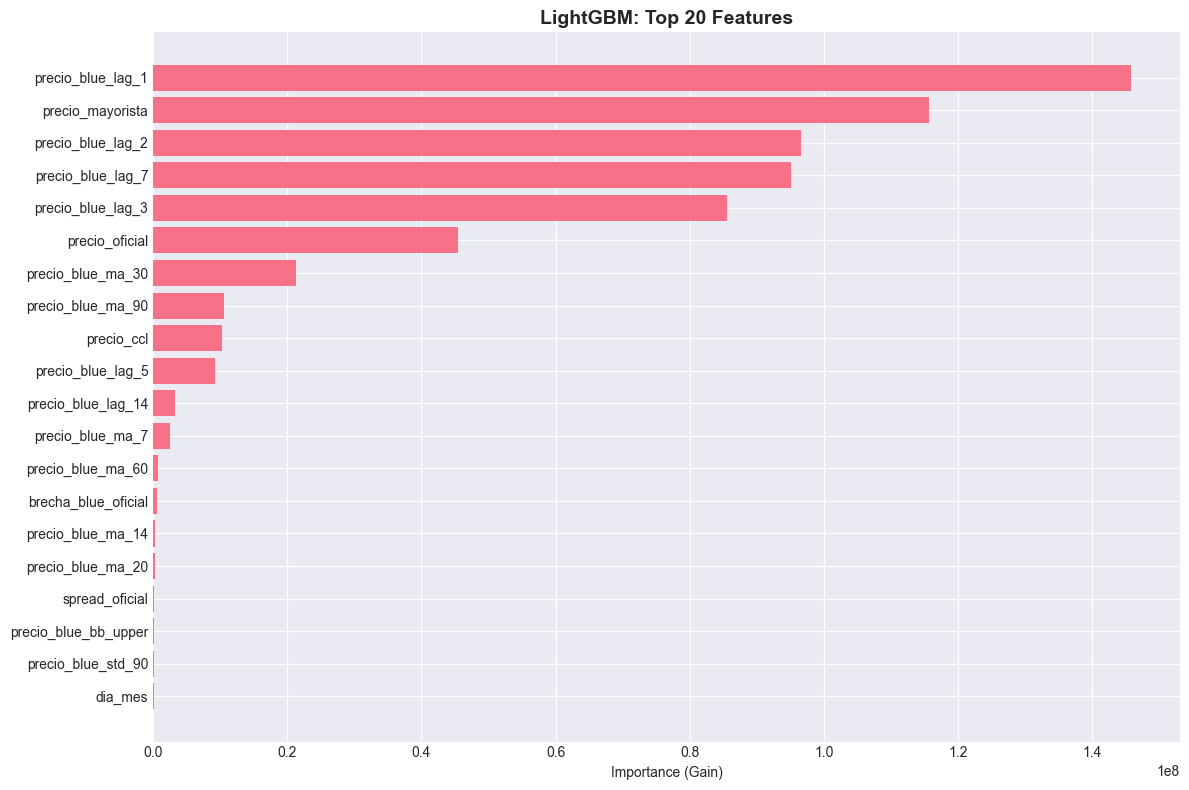


Top 10 features más importantes:
              feature    importance
7   precio_blue_lag_1  1.458103e+08
3    precio_mayorista  1.157305e+08
8   precio_blue_lag_2  9.656193e+07
11  precio_blue_lag_7  9.512211e+07
9   precio_blue_lag_3  8.552366e+07
0      precio_oficial  4.551024e+07
20  precio_blue_ma_30  2.125990e+07
24  precio_blue_ma_90  1.057838e+07
5          precio_ccl  1.020061e+07
10  precio_blue_lag_5  9.222528e+06


In [33]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgb_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance['feature'][:20], feature_importance['importance'][:20])
plt.xlabel('Importance (Gain)')
plt.title('LightGBM: Top 20 Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 10 features más importantes:')
print(feature_importance.head(10))

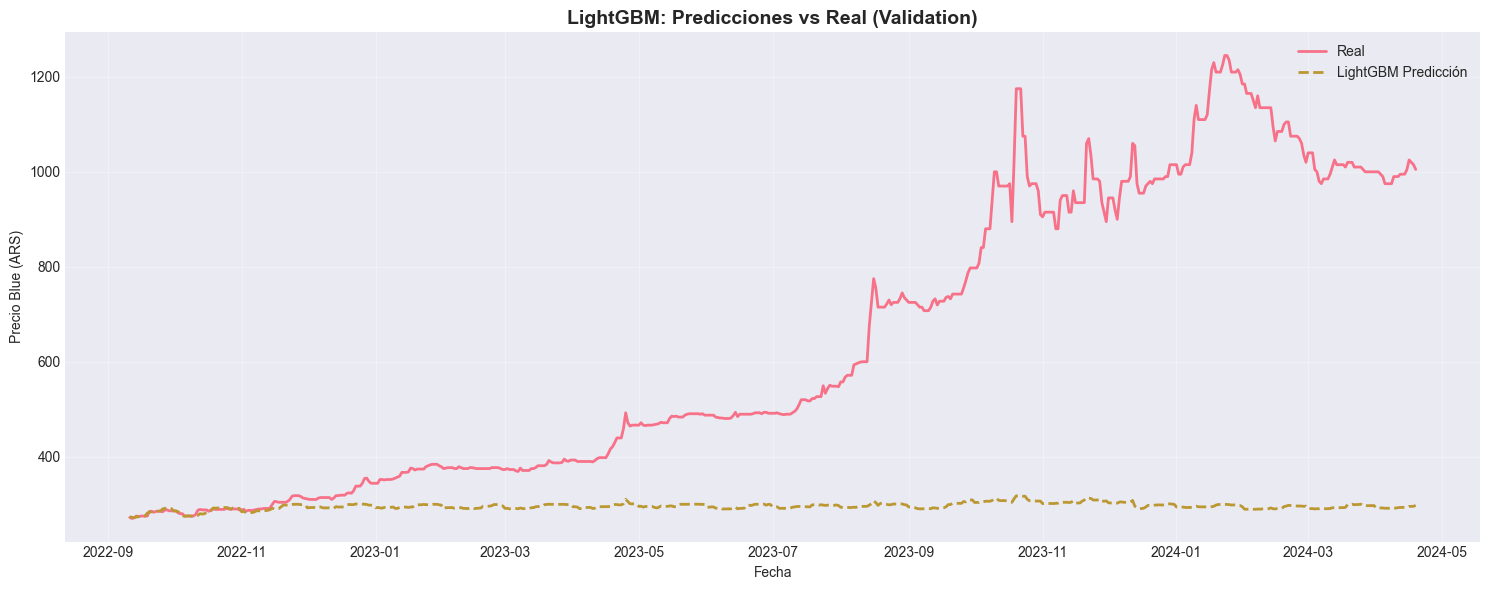

In [34]:
# Visualizar predicciones LightGBM
plt.figure(figsize=(15, 6))
plt.plot(val_data['fecha'], y_val.values, label='Real', linewidth=2)
plt.plot(val_data['fecha'], lgb_pred_val, label='LightGBM Predicción', linestyle='--', linewidth=2)
plt.title('LightGBM: Predicciones vs Real (Validation)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Precio Blue (ARS)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# Guardar modelo LightGBM
lgb_model.save_model('../src/models/models/lightgbm_model.txt')

lgb_results = {
    'model_name': 'LightGBM',
    'params': lgb_params,
    'best_iteration': lgb_model.best_iteration,
    'predictions_val': lgb_pred_val.tolist(),
    'metrics_val': {
        'mae': float(lgb_mae_val),
        'rmse': float(lgb_rmse_val),
        'mape': float(lgb_mape_val),
        'r2': float(lgb_r2_val)
    },
    'feature_importance': feature_importance.to_dict('records')
}

with open('../src/models/models/lightgbm_results.json', 'w') as f:
    json.dump(lgb_results, f, indent=4)

print('✓ Modelo LightGBM guardado en ../src/models/models/')

✓ Modelo LightGBM guardado en ../src/models/models/


## 10. Modelo 4: N-BEATS (Opcional - Requiere TensorFlow)

In [39]:
if not TF_AVAILABLE:
    print('⚠ N-BEATS omitido: TensorFlow no disponible')
    print('  Para instalar TensorFlow:')
    print('  pip install tensorflow')
    print('\n  Nota: En Windows, TensorFlow puede requerir Visual C++ Redistributable')
    print('  Descarga: https://aka.ms/vs/17/release/vc_redist.x64.exe')
    
    # Crear variables dummy para continuar
    nbeats_mae_val = None
    nbeats_rmse_val = None
    nbeats_mape_val = None
    nbeats_pred_val_denorm = None
else:
    print('✓ Iniciando entrenamiento de N-BEATS...')

⚠ N-BEATS omitido: TensorFlow no disponible
  Para instalar TensorFlow:
  pip install tensorflow

  Nota: En Windows, TensorFlow puede requerir Visual C++ Redistributable
  Descarga: https://aka.ms/vs/17/release/vc_redist.x64.exe


In [37]:
if TF_AVAILABLE:
    # Preparar datos para N-BEATS (secuencias)
    def create_sequences(data, lookback=60, forecast_horizon=30):
        """
        Crea secuencias para modelos de deep learning.
        """
        X, y = [], []
        for i in range(len(data) - lookback - forecast_horizon + 1):
            X.append(data[i:i + lookback])
            y.append(data[i + lookback:i + lookback + forecast_horizon])
        return np.array(X), np.array(y)
    
    lookback = 60
    forecast_horizon = 30
    
    # Normalizar datos
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    precio_blue_scaled = scaler.fit_transform(df_features_clean[['precio_blue']])
    
    # Crear secuencias
    X_seq, y_seq = create_sequences(precio_blue_scaled.flatten(), lookback, forecast_horizon)
    
    # División temporal
    train_seq_size = int(len(X_seq) * 0.70)
    val_seq_size = int(len(X_seq) * 0.15)
    
    X_train_seq = X_seq[:train_seq_size]
    y_train_seq = y_seq[:train_seq_size]
    X_val_seq = X_seq[train_seq_size:train_seq_size + val_seq_size]
    y_val_seq = y_seq[train_seq_size:train_seq_size + val_seq_size]
    X_test_seq = X_seq[train_seq_size + val_seq_size:]
    y_test_seq = y_seq[train_seq_size + val_seq_size:]
    
    print(f'X_train_seq shape: {X_train_seq.shape}')
    print(f'y_train_seq shape: {y_train_seq.shape}')
    print(f'X_val_seq shape: {X_val_seq.shape}')
    print(f'y_val_seq shape: {y_val_seq.shape}')

In [38]:
# Arquitectura N-BEATS simplificada
def build_nbeats_model(lookback, forecast_horizon):
    """
    Construye un modelo N-BEATS simplificado.
    """
    inputs = keras.Input(shape=(lookback,))
    
    # Stack 1: Trend
    x1 = layers.Dense(256, activation='relu')(inputs)
    x1 = layers.Dense(256, activation='relu')(x1)
    x1 = layers.Dense(256, activation='relu')(x1)
    x1 = layers.Dense(256, activation='relu')(x1)
    backcast1 = layers.Dense(lookback, name='backcast1')(x1)
    forecast1 = layers.Dense(forecast_horizon, name='forecast1')(x1)
    
    # Residual
    residual = layers.Subtract()([inputs, backcast1])
    
    # Stack 2: Seasonality
    x2 = layers.Dense(256, activation='relu')(residual)
    x2 = layers.Dense(256, activation='relu')(x2)
    x2 = layers.Dense(256, activation='relu')(x2)
    x2 = layers.Dense(256, activation='relu')(x2)
    forecast2 = layers.Dense(forecast_horizon, name='forecast2')(x2)
    
    # Combinar forecasts
    forecast = layers.Add()([forecast1, forecast2])
    
    model = keras.Model(inputs=inputs, outputs=forecast)
    return model

nbeats_model = build_nbeats_model(lookback, forecast_horizon)
nbeats_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

print('✓ Modelo N-BEATS construido')
nbeats_model.summary()

NameError: name 'lookback' is not defined

In [41]:
if TF_AVAILABLE:
    # Entrenar N-BEATS
    print('Entrenando modelo N-BEATS...')
    
    early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
    
    history = nbeats_model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    
    print('\n✓ Modelo N-BEATS entrenado')

In [42]:
if TF_AVAILABLE:
    # Visualizar curvas de aprendizaje
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('N-BEATS: Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.title('N-BEATS: MAE', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [43]:
if TF_AVAILABLE:
    # Predicciones N-BEATS
    nbeats_pred_val = nbeats_model.predict(X_val_seq)
    
    # Desnormalizar
    nbeats_pred_val_denorm = scaler.inverse_transform(nbeats_pred_val)
    y_val_seq_denorm = scaler.inverse_transform(y_val_seq)
    
    # Métricas (promedio sobre horizonte de predicción)
    nbeats_mae_val = mean_absolute_error(y_val_seq_denorm.flatten(), nbeats_pred_val_denorm.flatten())
    nbeats_rmse_val = np.sqrt(mean_squared_error(y_val_seq_denorm.flatten(), nbeats_pred_val_denorm.flatten()))
    nbeats_mape_val = np.mean(np.abs((y_val_seq_denorm - nbeats_pred_val_denorm) / y_val_seq_denorm)) * 100
    
    print('Métricas N-BEATS en Validation:')
    print(f'MAE: {nbeats_mae_val:.2f}')
    print(f'RMSE: {nbeats_rmse_val:.2f}')
    print(f'MAPE: {nbeats_mape_val:.2f}%')

In [44]:
if TF_AVAILABLE:
    # Visualizar predicciones N-BEATS (primeras 5 secuencias)
    fig, axes = plt.subplots(5, 1, figsize=(15, 15))
    
    for i in range(5):
        axes[i].plot(range(forecast_horizon), y_val_seq_denorm[i], label='Real', linewidth=2)
        axes[i].plot(range(forecast_horizon), nbeats_pred_val_denorm[i], label='N-BEATS', linestyle='--', linewidth=2)
        axes[i].set_title(f'Secuencia {i+1}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Días')
        axes[i].set_ylabel('Precio Blue (ARS)')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [45]:
if TF_AVAILABLE:
    # Guardar modelo N-BEATS
    nbeats_model.save('../src/models/models/nbeats_model.keras')
    
    # Guardar scaler
    with open('../src/models/models/nbeats_scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)
    
    nbeats_results = {
        'model_name': 'N-BEATS',
        'lookback': lookback,
        'forecast_horizon': forecast_horizon,
        'metrics_val': {
            'mae': float(nbeats_mae_val),
            'rmse': float(nbeats_rmse_val),
            'mape': float(nbeats_mape_val)
        },
        'training_history': {
            'loss': [float(x) for x in history.history['loss']],
            'val_loss': [float(x) for x in history.history['val_loss']]
        }
    }
    
    with open('../src/models/models/nbeats_results.json', 'w') as f:
        json.dump(nbeats_results, f, indent=4)
    
    print('✓ Modelo N-BEATS guardado en ../src/models/models/')

## 11. Comparación de Modelos

In [46]:
# Resumen de métricas
models_list = ['ARIMA', 'LightGBM']
mae_list = [arima_mae_val, lgb_mae_val]
rmse_list = [arima_rmse_val, lgb_rmse_val]
mape_list = [arima_mape_val, lgb_mape_val]

if TF_AVAILABLE and nbeats_mae_val is not None:
    models_list.append('N-BEATS')
    mae_list.append(nbeats_mae_val)
    rmse_list.append(nbeats_rmse_val)
    mape_list.append(nbeats_mape_val)

metrics_summary = pd.DataFrame({
    'Model': models_list,
    'MAE': mae_list,
    'RMSE': rmse_list,
    'MAPE (%)': mape_list
})

print('\n' + '='*60)
print('RESUMEN DE MÉTRICAS EN VALIDATION')
print('='*60)
print(metrics_summary.to_string(index=False))
print('='*60)

if not TF_AVAILABLE:
    print('\n⚠ N-BEATS no incluido (TensorFlow no disponible)')

# Guardar resumen
metrics_summary.to_csv('../src/models/models/metrics_summary.csv', index=False)
print('\n✓ Resumen guardado en ../src/models/models/metrics_summary.csv')


RESUMEN DE MÉTRICAS EN VALIDATION
   Model        MAE       RMSE  MAPE (%)
   ARIMA 366.795934 476.577101 46.423980
LightGBM 341.986693 455.706924 41.880009

⚠ N-BEATS no incluido (TensorFlow no disponible)

✓ Resumen guardado en ../src/models/models/metrics_summary.csv


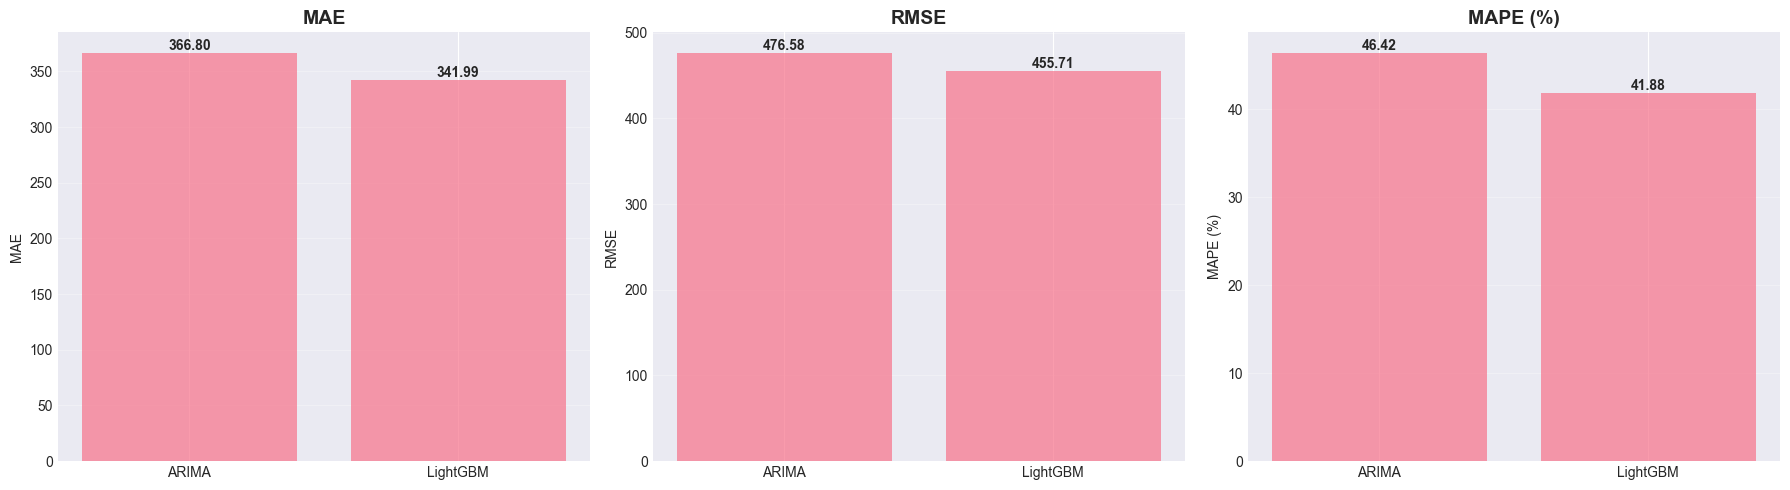

✓ Gráfico guardado en ../src/models/models/metrics_comparison.png


In [47]:
# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['MAE', 'RMSE', 'MAPE (%)']
for i, metric in enumerate(metrics):
    axes[i].bar(metrics_summary['Model'], metrics_summary[metric], alpha=0.7)
    axes[i].set_title(f'{metric}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].grid(True, alpha=0.3, axis='y')
    
    # Anotar valores
    for j, v in enumerate(metrics_summary[metric]):
        axes[i].text(j, v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../src/models/models/metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Gráfico guardado en ../src/models/models/metrics_comparison.png')

## 12. Preparación para Ensemble (Notebook 05)

In [48]:
# Guardar predicciones de todos los modelos para ensemble
ensemble_data = {
    'dates_val': val_data['fecha'].dt.strftime('%Y-%m-%d').tolist(),
    'y_true_val': y_val.tolist(),
    'predictions': {
        'arima': arima_pred_val.tolist(),
        'lightgbm': lgb_pred_val.tolist()
    },
    'volatility': {
        'garch': predicted_volatility.tolist()
    }
}

# Agregar N-BEATS si está disponible
if TF_AVAILABLE and nbeats_pred_val_denorm is not None:
    # N-BEATS tiene horizonte de 30 días, tomar solo primer día de cada secuencia
    ensemble_data['predictions']['nbeats'] = [float(pred[0]) for pred in nbeats_pred_val_denorm]

with open('../src/models/models/ensemble_predictions.json', 'w') as f:
    json.dump(ensemble_data, f, indent=4)

print('✓ Predicciones para ensemble guardadas en ../src/models/models/ensemble_predictions.json')
print(f'  Modelos incluidos: {list(ensemble_data["predictions"].keys())}')

✓ Predicciones para ensemble guardadas en ../src/models/models/ensemble_predictions.json
  Modelos incluidos: ['arima', 'lightgbm']


In [49]:
# Resumen final
print('\n' + '='*80)
print('RESUMEN FINAL - MODELOS ENTRENADOS Y GUARDADOS')
print('='*80)
print('\n1. ARIMA(5,1,2)')
print(f'   - MAE: {arima_mae_val:.2f} | RMSE: {arima_rmse_val:.2f} | MAPE: {arima_mape_val:.2f}%')
print('   - Archivos: arima_model.pkl, arima_results.json')

print('\n2. GARCH(1,1)')
print('   - Modelo de volatilidad')
print('   - Archivos: garch_model.pkl, garch_results.json')

print('\n3. LightGBM')
print(f'   - MAE: {lgb_mae_val:.2f} | RMSE: {lgb_rmse_val:.2f} | MAPE: {lgb_mape_val:.2f}% | R²: {lgb_r2_val:.4f}')
print('   - Archivos: lightgbm_model.txt, lightgbm_results.json')

if TF_AVAILABLE and nbeats_mae_val is not None:
    print('\n4. N-BEATS')
    print(f'   - MAE: {nbeats_mae_val:.2f} | RMSE: {nbeats_rmse_val:.2f} | MAPE: {nbeats_mape_val:.2f}%')
    print('   - Archivos: nbeats_model.keras, nbeats_scaler.pkl, nbeats_results.json')
else:
    print('\n4. N-BEATS')
    print('   - ⚠ OMITIDO (TensorFlow no disponible)')
    print('   - Para instalar: pip install tensorflow')

print('\n5. Datos para Ensemble')
print('   - Archivo: ensemble_predictions.json')
print('   - Contiene predicciones de todos los modelos disponibles en validation set')

print('\n' + '='*80)
print('✓ MODELOS LISTOS PARA ENSEMBLE EN NOTEBOOK 05')
print('='*80)


RESUMEN FINAL - MODELOS ENTRENADOS Y GUARDADOS

1. ARIMA(5,1,2)
   - MAE: 366.80 | RMSE: 476.58 | MAPE: 46.42%
   - Archivos: arima_model.pkl, arima_results.json

2. GARCH(1,1)
   - Modelo de volatilidad
   - Archivos: garch_model.pkl, garch_results.json

3. LightGBM
   - MAE: 341.99 | RMSE: 455.71 | MAPE: 41.88% | R²: -1.2429
   - Archivos: lightgbm_model.txt, lightgbm_results.json

4. N-BEATS
   - ⚠ OMITIDO (TensorFlow no disponible)
   - Para instalar: pip install tensorflow

5. Datos para Ensemble
   - Archivo: ensemble_predictions.json
   - Contiene predicciones de todos los modelos disponibles en validation set

✓ MODELOS LISTOS PARA ENSEMBLE EN NOTEBOOK 05


In [50]:
# No uso por ahora N-Beats por la version de Python